# DNA-GRU: Training Data Fraction Analysis (Srinivasavaradhan)

Empirical validation of the theoretical claim that DNA-GRU trains well on less data.
We retrain **only** on a fraction of the synthetic training set (5% / 20% / 50% / 80%)
while keeping the architecture, optimizer, schedule, and evaluation identical to the
100% reference run.

**Dataset:** Srinivasavaradhan et al. - Twist + Nanopore MinION.
Selected because it has the highest error rate among the public Nanopore benchmarks;
if DNA-GRU still trains well here on less data, the theoretical claim is
strongly supported.

**One run = one fraction.** Set `DATA_FRACTION` in the config cell below, then run all.
Each fraction writes to its own `Experiments/Srinivasavaradhan_v4_data{PCT}/` tree, so
nothing is overwritten.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

import os
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib
import scipy.io as sio

matplotlib.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif',
})

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.1.2
Using device: cuda
GPU: NVIDIA GeForce RTX 3080


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# Pick the fraction of training data to use. 1.0 reproduces the reference run.
# Run the notebook once per fraction; each run writes to its own directory.

DATASET_NAME = "Srinivasavaradhan"

DATA_FRACTION = 0.20   # <-- CHANGE THIS: 0.05 / 0.20 / 0.50 / 0.80
SUBSET_SEED  = 42      # fixed so subsamples are reproducible across reruns

# "train_and_eval"  | "train_only" | "eval_only"
RUN_MODE = "train_and_eval"

# =============================================================================
# DATASET CONFIG (Srinivasavaradhan)
# =============================================================================

DATASET_CONFIGS = {
    "Srinivasavaradhan": {
        "label_len": 110, "index_length": 4, "max_deviation": 10,
        "filter_index": False,
        "description": "Srinivasavaradhan et al. - Twist, MinION (high error)",
    },
}

DATASET_FILES = {
    "Srinivasavaradhan": ("binned_synthetic_srinivasavaradhan.txt", "Srinivasavaradhan.txt"),
}

CONFIG = DATASET_CONFIGS[DATASET_NAME]
LABEL_SEQ_LEN    = CONFIG["label_len"]
INDEX_LENGTH     = CONFIG["index_length"]
MAX_DEVIATION    = CONFIG["max_deviation"]
FILTER_INDEX     = CONFIG["filter_index"]
MAX_CLUSTER_SIZE = 16

ORIGINAL_SEQ_LEN = LABEL_SEQ_LEN + INDEX_LENGTH if FILTER_INDEX else LABEL_SEQ_LEN
MAX_READ_LEN     = ORIGINAL_SEQ_LEN + MAX_DEVIATION + 8

# =============================================================================
# TRAINING HYPERPARAMETERS  (identical to the 100% run)
# =============================================================================
BATCH_SIZE     = 200
LEARNING_RATE  = 5e-4
MIN_LR         = 5e-8
WEIGHT_DECAY   = 1e-5
EPOCHS         = 100
WARMUP_EPOCHS  = 10
PATIENCE       = 10

EMBED_DIM          = 300
ALIGNMENT_FILTERS  = 128
EMBEDDING_FILTERS  = 500
GRU_HIDDEN         = 300
GRU_LAYERS         = 2
DROPOUT            = 0.1

# =============================================================================
# PATHS  (the data-fraction tag goes in the directory name -> no overwrites)
# =============================================================================
SYNTHETIC_DATA_DIR = Path("../generated_data_corrected")
REAL_DATA_DIR      = Path("../Data")

_train_file, _eval_file = DATASET_FILES[DATASET_NAME]
TRAIN_FILE = SYNTHETIC_DATA_DIR / _train_file
EVAL_FILE  = REAL_DATA_DIR / _eval_file

# Directory tag from data fraction: 0.05 -> 'data005', 0.20 -> 'data020', ...
PCT_TAG     = f"data{int(round(DATA_FRACTION * 100)):03d}"
EXP_TAG     = f"{DATASET_NAME}_v4_{PCT_TAG}"

EXPERIMENT_DIR = Path(f"./Experiments/{EXP_TAG}")
WEIGHTS_DIR    = EXPERIMENT_DIR / 'Models'
RESULTS_DIR    = EXPERIMENT_DIR / 'Results'
FIGURES_DIR    = EXPERIMENT_DIR / 'Figures'
MAT_DIR        = EXPERIMENT_DIR / 'MatFiles'

for d in [WEIGHTS_DIR, RESULTS_DIR, FIGURES_DIR, MAT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_BEST_PATH  = WEIGHTS_DIR / f"best_model_{EXP_TAG}.pth"
MODEL_FINAL_PATH = WEIGHTS_DIR / f"final_model_{EXP_TAG}.pth"

print(f"\n{'='*70}")
print(f"DATA FRACTION ANALYSIS")
print(f"{'='*70}")
print(f"  Dataset:       {DATASET_NAME}")
print(f"  Description:   {CONFIG['description']}")
print(f"  DATA_FRACTION: {DATA_FRACTION}  (tag = {PCT_TAG})")
print(f"  RUN_MODE:      {RUN_MODE}")
print(f"  Experiment dir:{EXPERIMENT_DIR}")
print(f"  Train file:    {TRAIN_FILE}")
print(f"  Eval file:     {EVAL_FILE}")
print(f"  L (label):     {LABEL_SEQ_LEN} | T (max read): {MAX_READ_LEN}")
print(f"{'='*70}\n")


DATA FRACTION ANALYSIS
  Dataset:       Srinivasavaradhan
  Description:   Srinivasavaradhan et al. - Twist, MinION (high error)
  DATA_FRACTION: 0.2  (tag = data020)
  RUN_MODE:      train_and_eval
  Experiment dir:Experiments/Srinivasavaradhan_v4_data020
  Train file:    ../generated_data_corrected/binned_synthetic_srinivasavaradhan.txt
  Eval file:     ../Data/Srinivasavaradhan.txt
  L (label):     110 | T (max read): 128



In [3]:
# =============================================================================
# VOCABULARY + ENCODE/DECODE UTILS
# =============================================================================

VOCAB         = {'N': 0, 'A': 1, 'C': 2, 'G': 3, 'T': 4}
PADDING_IDX   = VOCAB['N']
VOCAB_SIZE    = len(VOCAB)
INT_TO_CHAR   = {i: c for c, i in VOCAB.items()}
DNA_BASES     = ['A', 'C', 'G', 'T']

def encode_seq(seq, char_to_int, max_len, padding_idx):
    encoded = [char_to_int.get(c, padding_idx) for c in seq]
    encoded = encoded[:max_len]
    return encoded + [padding_idx] * (max_len - len(encoded))

def decode_seq(tensor, int_to_char):
    if tensor.is_cuda:
        tensor = tensor.cpu()
    ints = tensor.numpy().tolist()
    try:
        first_pad = ints.index(PADDING_IDX)
        ints = ints[:first_pad]
    except ValueError:
        pass
    return "".join([int_to_char.get(i, '?') for i in ints])

In [4]:
# =============================================================================
# DATASET
# =============================================================================

class DnaClusterDataset(Dataset):
    def __init__(self, filepath, max_cluster_size, max_read_len, label_seq_len,
                 char_to_int, padding_idx):
        self.max_cluster_size = max_cluster_size
        self.max_read_len     = max_read_len
        self.label_seq_len    = label_seq_len
        self.char_to_int      = char_to_int
        self.padding_idx      = padding_idx
        self.labels   = []
        self.clusters = []
        self._load_data(filepath)

    def _load_data(self, filepath):
        print(f"Loading data from {filepath}...")
        with open(filepath, 'r') as f:
            content = f.read()
        blocks = content.split('\n\n')
        for block in tqdm(blocks, desc=f"Parsing {filepath.name}"):
            if not block.strip():
                continue
            lines = [l.strip() for l in block.strip().split('\n')]
            if len(lines) < 3:
                continue
            label_seq = lines[0]
            reads = [r for r in lines[2:] if r]
            if not reads or not label_seq:
                continue
            self.labels.append(label_seq)
            self.clusters.append(reads)
        print(f"Loaded {len(self.labels)} clusters.")
        if self.labels:
            actual = len(self.labels[0])
            print(f"  Label length in file: {actual}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label_str = self.labels[idx]
        reads     = list(self.clusters[idx])
        label_t = torch.tensor(
            encode_seq(label_str, self.char_to_int, self.label_seq_len, self.padding_idx),
            dtype=torch.long)
        cluster_t = torch.full((self.max_cluster_size, self.max_read_len),
                               self.padding_idx, dtype=torch.long)
        random.shuffle(reads)
        for i, r in enumerate(reads[:self.max_cluster_size]):
            cluster_t[i] = torch.tensor(
                encode_seq(r, self.char_to_int, self.max_read_len, self.padding_idx),
                dtype=torch.long)
        return cluster_t, label_t

    def get_raw_reads(self, idx):    return self.clusters[idx]
    def get_raw_label(self, idx):    return self.labels[idx]
    def get_cluster_size(self, idx): return len(self.clusters[idx])

In [5]:
# =============================================================================
# MODEL  (DNA-GRU - identical to the reference notebook)
# =============================================================================

class DepthwiseSeparableConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=0):
        super().__init__()
        self.depthwise = nn.Conv1d(in_channels, in_channels, kernel_size=kernel_size,
                                   padding=padding, groups=in_channels)
        self.pointwise = nn.Conv1d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.pointwise(self.depthwise(x))

class MultiKernelConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, seq_len, dropout=0.1):
        super().__init__()
        c1 = out_channels // 3
        c2 = out_channels // 3
        c3 = out_channels - c1 - c2
        self.conv1 = DepthwiseSeparableConv1d(in_channels, c1, kernel_size=1)
        self.conv3 = DepthwiseSeparableConv1d(in_channels, c2, kernel_size=3, padding=1)
        self.conv5 = DepthwiseSeparableConv1d(in_channels, c3, kernel_size=5, padding=2)
        self.norm1 = nn.LayerNorm([c1, seq_len])
        self.norm2 = nn.LayerNorm([c2, seq_len])
        self.norm3 = nn.LayerNorm([c3, seq_len])
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x1 = F.gelu(self.norm1(self.conv1(x)))
        x2 = F.gelu(self.norm2(self.conv3(x)))
        x3 = F.gelu(self.norm3(self.conv5(x)))
        return self.dropout(torch.cat([x1, x2, x3], dim=1))

class AlignmentModule(nn.Module):
    def __init__(self, embed_dim, out_channels, seq_len, dropout=0.1):
        super().__init__()
        self.conv_block1 = MultiKernelConvBlock(embed_dim, out_channels, seq_len, dropout)
        self.conv_block2 = MultiKernelConvBlock(out_channels, out_channels, seq_len, dropout)
    def forward(self, x):
        batch, cluster, emb, seq = x.shape
        x = x.view(batch * cluster, emb, seq)
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        return x.view(batch, cluster, -1, seq)

class EmbeddingModule(nn.Module):
    def __init__(self, in_channels, out_channels, in_len, out_len, dropout=0.1):
        super().__init__()
        self.conv_block = MultiKernelConvBlock(in_channels, out_channels, in_len, dropout)
        self.linear     = nn.Linear(in_len, out_len)
    def forward(self, x):
        x = self.conv_block(x)
        batch, channels, seq_len = x.shape
        x = x.reshape(batch * channels, seq_len)
        x = self.linear(x)
        return x.reshape(batch, channels, -1)

class ImprovedDNAReconstructionModel(nn.Module):
    def __init__(self, vocab_size, label_seq_len, max_read_len, padding_idx,
                 embed_dim=300, alignment_filters=128, embedding_filters=500,
                 gru_hidden=300, gru_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.alignment = AlignmentModule(embed_dim, alignment_filters, max_read_len, dropout)
        self.embedding_module = EmbeddingModule(
            alignment_filters, embedding_filters, max_read_len, label_seq_len, dropout)
        self.gru = nn.GRU(embedding_filters, gru_hidden, num_layers=gru_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if gru_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(gru_hidden * 2, vocab_size)

    def forward(self, cluster_batch, return_probs=False):
        emb     = self.embedding(cluster_batch).permute(0, 1, 3, 2)
        aligned = self.alignment(emb)
        nci     = torch.sum(aligned, dim=1)
        feats   = self.embedding_module(nci).permute(0, 2, 1)
        gru_out, _ = self.gru(feats)
        logits  = self.fc_out(self.dropout(gru_out))
        if return_probs:
            return logits, F.softmax(logits, dim=2)
        return logits

In [6]:
# =============================================================================
# OPTIMIZER + COSINE SCHEDULER WITH WARMUP
# =============================================================================

class CosineAnnealingWarmupScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, max_lr, min_lr):
        self.optimizer     = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.max_lr        = max_lr
        self.min_lr        = min_lr
        self.current_epoch = 0
    def step(self):
        if self.current_epoch < self.warmup_epochs:
            lr = self.max_lr * (self.current_epoch + 1) / self.warmup_epochs
        else:
            progress = (self.current_epoch - self.warmup_epochs) / \
                       (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + (self.max_lr - self.min_lr) * 0.5 * (1 + math.cos(math.pi * progress))
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        self.current_epoch += 1
        return lr
    def get_last_lr(self):
        return [pg['lr'] for pg in self.optimizer.param_groups]

In [7]:
# =============================================================================
# TRAIN / VALIDATE FUNCTIONS
# =============================================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    loop = tqdm(loader, desc="Training", leave=False)
    for clusters, labels in loop:
        clusters, labels = clusters.to(device), labels.to(device)
        logits = model(clusters)
        loss = criterion(logits.view(-1, VOCAB_SIZE), labels.view(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())
    return total_loss / max(len(loader), 1)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    loop = tqdm(loader, desc="Validating", leave=False)
    with torch.no_grad():
        for clusters, labels in loop:
            clusters, labels = clusters.to(device), labels.to(device)
            logits = model(clusters)
            loss = criterion(logits.view(-1, VOCAB_SIZE), labels.view(-1))
            total_loss += loss.item()
    return total_loss / max(len(loader), 1)

In [8]:
# =============================================================================
# BUILD SUBSAMPLED TRAIN / VAL LOADERS
# =============================================================================
# Strategy:
#   1. Load the full synthetic training file (1.5M clusters).
#   2. Deterministically permute indices with SUBSET_SEED (so 5%, 20%, 50%, 80%
#      are nested -> fair, monotonic comparison).
#   3. Take the first ceil(N * DATA_FRACTION) indices as the working pool.
#   4. Split that pool into train/val with the existing 2% rule.

if RUN_MODE in ("train_and_eval", "train_only"):
    assert TRAIN_FILE.exists(), f"Training file not found: {TRAIN_FILE}"

    print(f"\n{'='*70}\nLOADING TRAINING DATA\n{'='*70}\n")
    full_train_dataset = DnaClusterDataset(
        TRAIN_FILE, MAX_CLUSTER_SIZE, MAX_READ_LEN,
        LABEL_SEQ_LEN, VOCAB, PADDING_IDX)

    N_full = len(full_train_dataset)

    # Deterministic permutation -> nested subsets across fractions
    g_subset = torch.Generator().manual_seed(SUBSET_SEED)
    perm = torch.randperm(N_full, generator=g_subset).tolist()

    n_use = int(math.ceil(N_full * DATA_FRACTION))
    use_indices = perm[:n_use]
    pool_dataset = Subset(full_train_dataset, use_indices)

    # Train / val split (val = 2% of the SUBSAMPLED pool, matching reference convention)
    val_size = int(0.02 * len(pool_dataset))
    if val_size < BATCH_SIZE:
        val_size = min(BATCH_SIZE * 2, len(pool_dataset) // 10)
    train_size = len(pool_dataset) - val_size
    g_split = torch.Generator().manual_seed(SUBSET_SEED + 1)
    train_dataset, val_dataset = random_split(pool_dataset, [train_size, val_size], generator=g_split)

    print(f"  Full training pool:     {N_full:,}")
    print(f"  Using fraction:         {DATA_FRACTION}  ({n_use:,} clusters)")
    print(f"  Train / Val split:      {train_size:,} / {val_size:,}")

    train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)


LOADING TRAINING DATA

Loading data from ../generated_data_corrected/binned_synthetic_srinivasavaradhan.txt...


Parsing binned_synthetic_srinivasavaradhan.txt:   0%|          | 0/1500001 [00:00<?, ?it/s]

Loaded 1500000 clusters.
  Label length in file: 110
  Full training pool:     1,500,000
  Using fraction:         0.2  (300,000 clusters)
  Train / Val split:      294,000 / 6,000


Model: 3,405,643 parameters

TRAINING: Srinivasavaradhan | DATA_FRACTION=0.2



Training:   0%|          | 0/1470 [00:00<?, ?it/s]

Validating:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1/100 | LR: 5.00e-04 | Train: 0.7969 | Val: 0.6294 | Time: 350.2s  ✓ BEST (↓inf)


Training:   0%|          | 0/1470 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch  77/100 | LR: 8.93e-05 | Train: 0.4682 | Val: 0.4811 | Time: 349.3s


Training:   0%|          | 0/1470 [00:00<?, ?it/s]

Validating:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch  78/100 | LR: 8.28e-05 | Train: 0.4677 | Val: 0.4809 | Time: 348.7s

Early stopping at epoch 78 (no val improvement for 10 epochs)

Best val loss: 0.4785 at epoch 68
Best  model -> Experiments/Srinivasavaradhan_v4_data020/Models/best_model_Srinivasavaradhan_v4_data020.pth
Final model -> Experiments/Srinivasavaradhan_v4_data020/Models/final_model_Srinivasavaradhan_v4_data020.pth
History CSV  -> Experiments/Srinivasavaradhan_v4_data020/Results/history_Srinivasavaradhan_v4_data020.csv


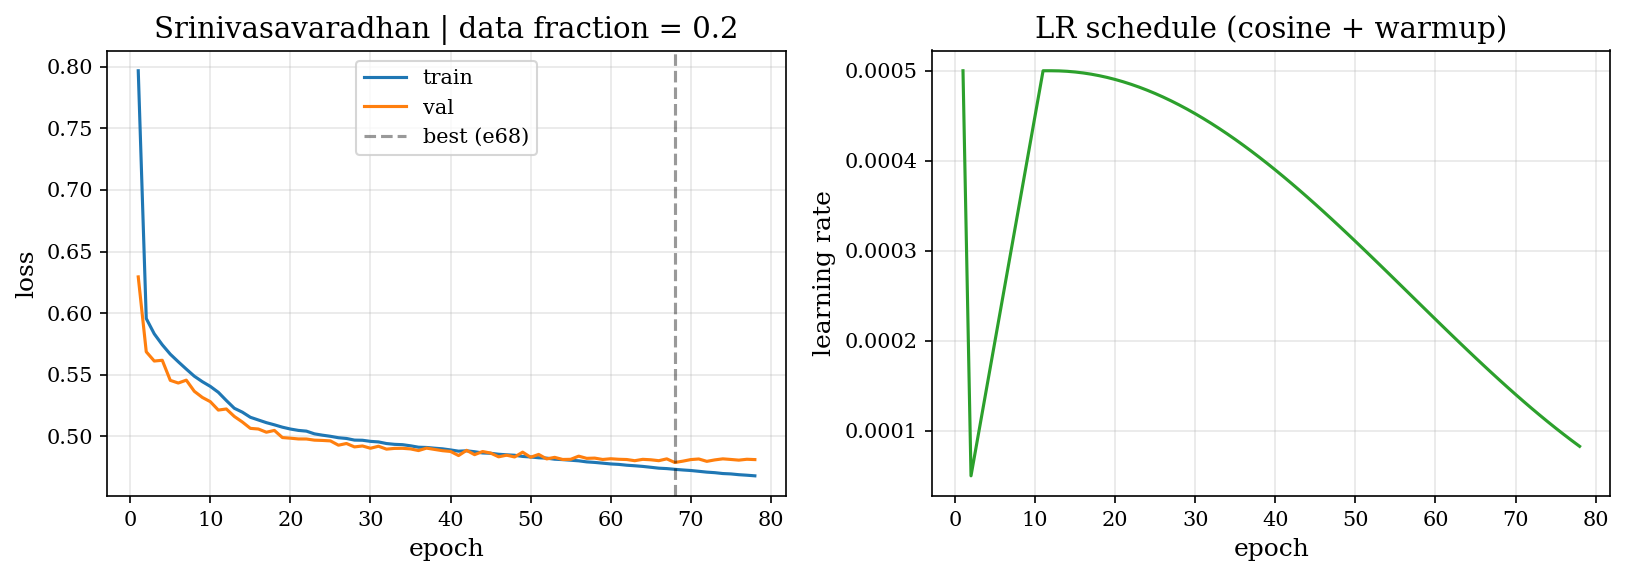

In [9]:
# =============================================================================
# TRAINING LOOP  (cosine + warmup, patience early stopping, save best & final)
# =============================================================================

if RUN_MODE in ("train_and_eval", "train_only"):
    model = ImprovedDNAReconstructionModel(
        VOCAB_SIZE, LABEL_SEQ_LEN, MAX_READ_LEN, PADDING_IDX,
        EMBED_DIM, ALIGNMENT_FILTERS, EMBEDDING_FILTERS,
        GRU_HIDDEN, GRU_LAYERS, DROPOUT).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model: {n_params:,} parameters")

    criterion = nn.CrossEntropyLoss(ignore_index=PADDING_IDX, label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmupScheduler(
        optimizer, WARMUP_EPOCHS, EPOCHS, LEARNING_RATE, MIN_LR)

    print(f"\n{'='*70}\nTRAINING: {DATASET_NAME} | DATA_FRACTION={DATA_FRACTION}\n{'='*70}\n")

    best_val_loss   = float('inf')
    patience_counter = 0
    train_losses, val_losses, learning_rates = [], [], []
    best_epoch = 0

    t_start = time.time()
    for epoch in range(EPOCHS):
        t0 = time.time()
        current_lr = scheduler.get_last_lr()[0]
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss   = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        learning_rates.append(current_lr)

        msg = (f"Epoch {epoch+1:3d}/{EPOCHS} | LR: {current_lr:.2e} | "
               f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
               f"Time: {time.time()-t0:.1f}s")
        if val_loss < best_val_loss:
            imp = best_val_loss - val_loss
            best_val_loss = val_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), MODEL_BEST_PATH)
            print(msg + f"  \u2713 BEST (\u2193{imp:.4f})")
            patience_counter = 0
        else:
            print(msg)
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no val improvement for {PATIENCE} epochs)")
            break

    # Final-state model (after last completed epoch)
    torch.save(model.state_dict(), MODEL_FINAL_PATH)

    # Save loss history
    history_df = pd.DataFrame({
        'epoch':         range(1, len(train_losses) + 1),
        'train_loss':    train_losses,
        'val_loss':      val_losses,
        'learning_rate': learning_rates,
    })
    history_df.to_csv(RESULTS_DIR / f"history_{EXP_TAG}.csv", index=False)

    sio.savemat(str(MAT_DIR / f"history_{EXP_TAG}.mat"), {
        'dataset_name':   DATASET_NAME,
        'data_fraction':  np.float64(DATA_FRACTION),
        'n_train':        np.float64(train_size),
        'n_val':          np.float64(val_size),
        'n_pool':         np.float64(n_use),
        'epochs':         np.array(history_df['epoch'].values, dtype=np.float64),
        'train_loss':     np.array(train_losses, dtype=np.float64),
        'val_loss':       np.array(val_losses, dtype=np.float64),
        'learning_rate':  np.array(learning_rates, dtype=np.float64),
        'best_val_loss':  np.float64(best_val_loss),
        'best_epoch':     np.float64(best_epoch),
        'total_train_time_sec': np.float64(time.time() - t_start),
    })

    print(f"\nBest val loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Best  model -> {MODEL_BEST_PATH}")
    print(f"Final model -> {MODEL_FINAL_PATH}")
    print(f"History CSV  -> {RESULTS_DIR / f'history_{EXP_TAG}.csv'}")

    # quick loss curve
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(range(1, len(train_losses)+1), train_losses, label='train')
    ax[0].plot(range(1, len(val_losses)+1),   val_losses,   label='val')
    ax[0].axvline(best_epoch, ls='--', c='k', alpha=0.4, label=f'best (e{best_epoch})')
    ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
    ax[0].set_title(f'{DATASET_NAME} | data fraction = {DATA_FRACTION}')
    ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(range(1, len(learning_rates)+1), learning_rates, c='C2')
    ax[1].set_xlabel('epoch'); ax[1].set_ylabel('learning rate')
    ax[1].set_title('LR schedule (cosine + warmup)')
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"loss_curve_{EXP_TAG}.png")
    plt.show()

    if RUN_MODE == "train_only":
        print(f"\n{'='*70}\nTRAINING COMPLETE (train_only)\n{'='*70}")
else:
    print(f"Skipping training (RUN_MODE='{RUN_MODE}')")

In [9]:
# =============================================================================
# LOAD BEST MODEL + TEST DATA  (real Srinivasavaradhan reads)
# =============================================================================

if RUN_MODE != "train_only":
    assert EVAL_FILE.exists(),  f"Eval file not found: {EVAL_FILE}"
    assert MODEL_BEST_PATH.exists(), f"Best model not found: {MODEL_BEST_PATH}"

    print(f"\n{'='*70}\nLOADING BEST MODEL\n{'='*70}")
    model = ImprovedDNAReconstructionModel(
        VOCAB_SIZE, LABEL_SEQ_LEN, MAX_READ_LEN, PADDING_IDX,
        EMBED_DIM, ALIGNMENT_FILTERS, EMBEDDING_FILTERS,
        GRU_HIDDEN, GRU_LAYERS, DROPOUT).to(DEVICE)
    model.load_state_dict(torch.load(str(MODEL_BEST_PATH), map_location=DEVICE, weights_only=True))
    model.eval()
    print(f"\u2713 Loaded ({sum(p.numel() for p in model.parameters()):,} params) from {MODEL_BEST_PATH}")

    test_ds = DnaClusterDataset(EVAL_FILE, MAX_CLUSTER_SIZE, MAX_READ_LEN,
                                LABEL_SEQ_LEN, VOCAB, PADDING_IDX)
    test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)
    print(f"Test clusters: {len(test_ds):,}")


LOADING BEST MODEL
✓ Loaded (3,405,643 params) from Experiments/Srinivasavaradhan_v4_data020/Models/best_model_Srinivasavaradhan_v4_data020.pth
Loading data from ../Data/Srinivasavaradhan.txt...


/homes/shubham/anaconda3/envs/pytorchenv/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Parsing Srinivasavaradhan.txt:   0%|          | 0/9955 [00:00<?, ?it/s]

Loaded 9954 clusters.
  Label length in file: 110
Test clusters: 9,954


In [10]:
# =============================================================================
# EVALUATION: DNN-only failure rate on real test data
# =============================================================================

if RUN_MODE != "train_only":
    print(f"\n{'='*70}\nEVALUATION (DNN-only)\n{'='*70}\n")

    # fix seed so this run's eval is reproducible (read shuffling inside dataset is
    # the only source of stochasticity; we report mean+std over N_EVAL_RUNS below)
    N_EVAL_RUNS = 100
    run_failures = []
    run_failure_indices = []

    for run in range(N_EVAL_RUNS):
        random.seed(run); np.random.seed(run)
        # rebuild dataset so internal read order is reshuffled
        eval_ds = DnaClusterDataset(EVAL_FILE, MAX_CLUSTER_SIZE, MAX_READ_LEN,
                                    LABEL_SEQ_LEN, VOCAB, PADDING_IDX)
        eval_loader = DataLoader(eval_ds, BATCH_SIZE, shuffle=False,
                                 num_workers=0, pin_memory=True)
        all_preds, all_labels = [], []
        with torch.no_grad():
            for clusters, labels in tqdm(eval_loader, desc=f"Eval run {run+1}/{N_EVAL_RUNS}"):
                logits = model(clusters.to(DEVICE))
                preds = logits.argmax(dim=2).cpu()
                for i in range(labels.shape[0]):
                    all_preds.append(preds[i])
                    all_labels.append(labels[i])
        N = len(all_preds)
        failed_idx = [i for i in range(N)
                      if decode_seq(all_preds[i], INT_TO_CHAR) != decode_seq(all_labels[i], INT_TO_CHAR)]
        run_failures.append(len(failed_idx))
        run_failure_indices.append(set(failed_idx))
        print(f"  Run {run+1}: {len(failed_idx):,}/{N:,} failures "
              f"({len(failed_idx)/N*100:.4f}%)")

    failures_arr = np.array(run_failures)
    rates_arr    = failures_arr / N * 100
    always_failed   = set.intersection(*run_failure_indices) if run_failure_indices else set()
    sometimes_failed = set().union(*run_failure_indices) - always_failed

    summary = {
        'dataset':            DATASET_NAME,
        'data_fraction':      DATA_FRACTION,
        'n_test':             N,
        'n_eval_runs':        N_EVAL_RUNS,
        'mean_failures':      float(failures_arr.mean()),
        'std_failures':       float(failures_arr.std()),
        'mean_rate_pct':      float(rates_arr.mean()),
        'std_rate_pct':       float(rates_arr.std()),
        'min_failures':       int(failures_arr.min()),
        'max_failures':       int(failures_arr.max()),
        'always_failed':      len(always_failed),
        'sometimes_failed':   len(sometimes_failed),
        'best_model_path':    str(MODEL_BEST_PATH),
    }
    print(f"\nDNN-only failure rate: {rates_arr.mean():.4f}% \u00b1 {rates_arr.std():.4f}% "
          f"(mean \u00b1 std over {N_EVAL_RUNS} runs)")
    print(f"Always failed:    {len(always_failed)}")
    print(f"Sometimes failed: {len(sometimes_failed)}")

    pd.DataFrame([summary]).to_csv(
        RESULTS_DIR / f"eval_summary_{EXP_TAG}.csv", index=False)
    pd.DataFrame({
        'run':       range(1, N_EVAL_RUNS+1),
        'failures':  run_failures,
        'rate_pct':  rates_arr.tolist(),
    }).to_csv(RESULTS_DIR / f"eval_runs_{EXP_TAG}.csv", index=False)

    sio.savemat(str(MAT_DIR / f"eval_summary_{EXP_TAG}.mat"), {
        'dataset_name':       DATASET_NAME,
        'data_fraction':      np.float64(DATA_FRACTION),
        'n_test':             np.float64(N),
        'n_eval_runs':        np.float64(N_EVAL_RUNS),
        'failures_per_run':   failures_arr.astype(np.float64),
        'rates_per_run':      rates_arr,
        'mean_failures':      np.float64(failures_arr.mean()),
        'std_failures':       np.float64(failures_arr.std()),
        'mean_rate_pct':      np.float64(rates_arr.mean()),
        'std_rate_pct':       np.float64(rates_arr.std()),
        'always_failed':      np.float64(len(always_failed)),
        'sometimes_failed':   np.float64(len(sometimes_failed)),
    })
    print(f"\nResults saved to: {RESULTS_DIR}")
    print(f"Mat files saved to: {MAT_DIR}")


EVALUATION (DNN-only)

Loading data from ../Data/Srinivasavaradhan.txt...


Parsing Srinivasavaradhan.txt:   0%|          | 0/9955 [00:00<?, ?it/s]

Loaded 9954 clusters.
  Label length in file: 110


Eval run 1/100:   0%|          | 0/50 [00:00<?, ?it/s]

  Run 1: 1,983/9,954 failures (19.9216%)
Loading data from ../Data/Srinivasavaradhan.txt...


...

  Run 99: 1,971/9,954 failures (19.8011%)
Loading data from ../Data/Srinivasavaradhan.txt...


Parsing Srinivasavaradhan.txt:   0%|          | 0/9955 [00:00<?, ?it/s]

Loaded 9954 clusters.
  Label length in file: 110


Eval run 100/100:   0%|          | 0/50 [00:00<?, ?it/s]

  Run 100: 1,977/9,954 failures (19.8614%)

DNN-only failure rate: 19.9015% ± 0.1024% (mean ± std over 100 runs)
Always failed:    1748
Sometimes failed: 1185

Results saved to: Experiments/Srinivasavaradhan_v4_data020/Results
Mat files saved to: Experiments/Srinivasavaradhan_v4_data020/MatFiles


---
### How to run the full sweep

1. Set `DATA_FRACTION = 0.05` -> run all -> writes to `Experiments/Srinivasavaradhan_v4_data005/`
2. Set `DATA_FRACTION = 0.20` -> run all -> writes to `Experiments/Srinivasavaradhan_v4_data020/`
3. Set `DATA_FRACTION = 0.50` -> run all -> writes to `Experiments/Srinivasavaradhan_v4_data050/`
4. Set `DATA_FRACTION = 0.80` -> run all -> writes to `Experiments/Srinivasavaradhan_v4_data080/`

Your existing 100% run is at `Experiments/Srinivasavaradhan_v4/`. Combine the five
`eval_summary_*.csv` files later for the final fraction-vs-failure-rate plot.

**Notes**
- Subsamples are nested by `SUBSET_SEED=42`: the 5% subset is contained in 20%, which
  is contained in 50%, which is contained in 80%, which is contained in 100%. This
  removes confounding from random subset choice across runs.
- Patience-based early stopping handles the much shorter epochs at low fractions
  automatically -- you do not need to retune `EPOCHS` or `PATIENCE`.
- The validation split is 2% of the **subsampled** pool (not of the full data),
  matching the existing convention. At 5% data the val set drops to ~1.5k clusters,
  which is still enough for a stable signal at batch size 200.